In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assay_readout_path = r"C:\Users\GOFKV\PycharmProjects\seqTeleporter\experiments\fluorescence_protein\assay\Copy of 241212_Me-En_FIScan.xlsx"
df_green = pd.read_excel(assay_readout_path, sheet_name="Plate 1_", header=0, index_col=0, skiprows=99, nrows=36).dropna()
df_blue = pd.read_excel(assay_readout_path, sheet_name="Plate 1_", header=0, index_col=0, skiprows=162).dropna()
df_blue = pd.read_excel(assay_readout_path, sheet_name="Plate 1", header=0, index_col=0, skiprows=163).dropna()

In [ ]:
df_green

In [ ]:
# Function to convert wavelength to RGB
def wavelength_to_rgb(wavelength):
    if 380 <= wavelength < 440:
        R = -(wavelength - 440) / (440 - 380)
        G = 0.0
        B = 1.0
    elif 440 <= wavelength < 490:
        R = 0.0
        G = (wavelength - 440) / (490 - 440)
        B = 1.0
    elif 490 <= wavelength < 510:
        R = 0.0
        G = 1.0
        B = -(wavelength - 510) / (510 - 490)
    elif 510 <= wavelength < 580:
        R = (wavelength - 510) / (580 - 510)
        G = 1.0
        B = 0.0
    elif 580 <= wavelength < 645:
        R = 1.0
        G = -(wavelength - 645) / (645 - 580)
        B = 0.0
    elif 645 <= wavelength <= 780:
        R = 1.0
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0

    return (R, G, B)

def create_rgb_dict(df):
    # Wavelengths corresponding to the rows
    wavelengths = df.index

    # Dictionary to hold the RGB values for each sample
    rgb_dict = {}

    # Iterate through each column in the DataFrame
    for column in df.columns:
        intensities = df[column].values
        intensities_normalized = intensities / np.max(intensities)  # Normalize intensity

        # Convert the spectrum to RGB
        rgb_values = np.array([wavelength_to_rgb(w) for w in wavelengths])

        # Calculate the final color by weighting the RGB values with the normalized intensities
        final_color = np.dot(rgb_values.T, intensities_normalized)

        # Store the result in the dictionary
        rgb_dict[column] = final_color

    # Find the maximum value across all arrays
    max_value = max(max(arr) for arr in rgb_dict.values())
    # Normalize the final color to be in the range [0, 1]
    rgb_dict_normalized = {}
    for k, v in rgb_dict.items():
        rgb_dict_normalized[k] = v / max(v)

    return rgb_dict_normalized

def draw(rgb_dict):
    # Create a colored grid for the 96-well plate
    grid_colors = np.zeros((8, 12, 3))  # Initialize a grid for 8 rows and 12 columns

    # Fill the grid with RGB values from the dictionary
    for i, row in enumerate("ABCDEFGH"):
        for j in range(1, 13):
            well_name = f"{row}{j}"
            if well_name in rgb_dict:
                grid_colors[i, j - 1] = rgb_dict[well_name]

    # Create a figure
    plt.figure(figsize=(12, 8))

    # Display the grid
    plt.imshow(grid_colors, aspect='auto')
    plt.xticks(np.arange(12), [f"{i+1}" for i in range(12)])  # Column numbers
    plt.yticks(np.arange(8), list("ABCDEFGH"))  # Row letters
    plt.title("Colored Grid of 96-Well Plate Samples")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.grid(False)  # Disable the grid lines
    plt.show()

In [ ]:
rgb_dict = create_rgb_dict(df_green)
draw(rgb_dict)

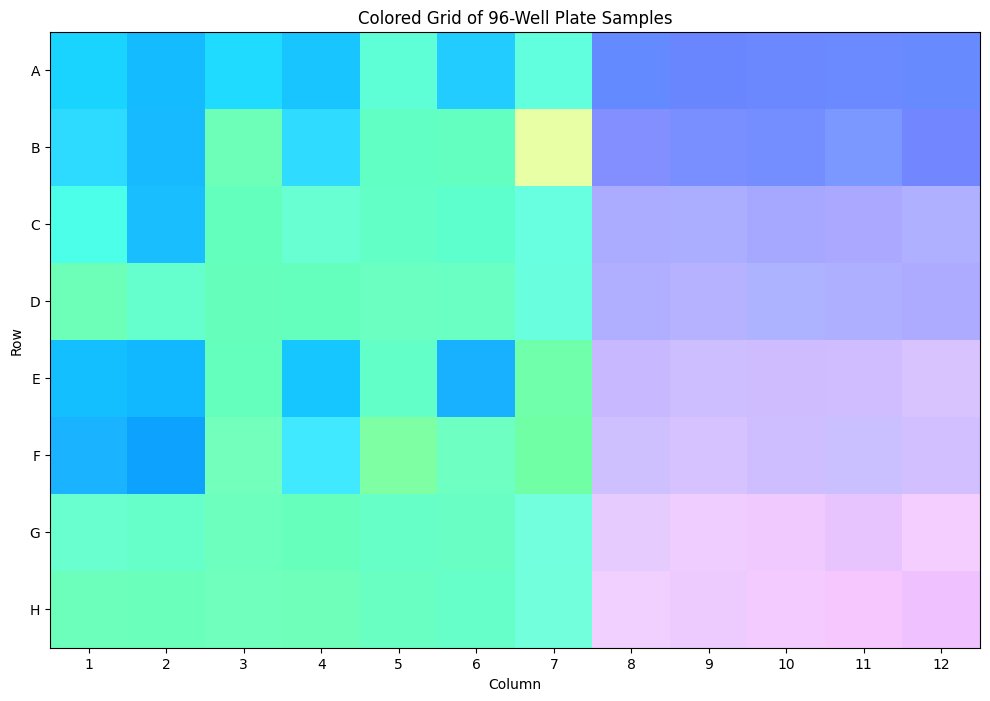

In [87]:
rgb_dict = create_rgb_dict(df_blue)
draw(rgb_dict)